# Part 1 — Data Preparation & Leakage-Free Pipeline
**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle) · **Course project | Assignment 1 | CLO-2**

**Contents:** 1. Problem framing · 2. Data loading · 3. EDA (6 visualisations) · 4. Train/test split · 5. Preprocessing design · 6. Leakage-free pipeline · 7. Leakage demonstration · 8. Save & summary

## 1. Problem Framing

| Item | Description |
|---|---|
| **Problem** | Predict whether an employee will leave the company (attrition) so HR can intervene early with retention actions (e.g. workload, promotion, compensation). |
| **Target variable** | `Attrition` (Yes → 1, No → 0) |
| **Task type** | Supervised **binary classification** |
| **Success metric** | **PR-AUC (average precision)** as primary metric; **recall and F1 on the "Yes" class** as secondary. Accuracy is *not* used: only ~16% of employees leave, so predicting "stays" for everyone gives ~84% accuracy while catching nobody. |
| **Dataset** | IBM HR Analytics Employee Attrition dataset (fictional data created by IBM data scientists): 1,470 employees, 34 features + target. Features cover demographics, job role, compensation, satisfaction ratings, tenure and overtime. |
| **Why suitable** | (i) clear, business-relevant binary target; (ii) mix of numeric, ordinal and nominal features that exercises every preprocessing step; (iii) real class imbalance (~16/84); (iv) several skewed variables with outliers (income, tenure); (v) constant/identifier columns that must be removed; (vi) small enough for rigorous cross-validation. |

## 2. Data Loading
Download `WA_Fn-UseC_-HR-Employee-Attrition.csv` from Kaggle and place it next to this notebook (or in Colab, upload it / use the optional `kagglehub` cell).

In [1]:
import os, warnings
from functools import partial
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
CSV_PATH = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
TARGET = "Attrition"

In [2]:
# OPTIONAL (Colab / internet + Kaggle account): download with kagglehub
# import kagglehub, glob
# path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
# CSV_PATH = glob.glob(path + "/*.csv")[0]

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 2.1 Initial data audit

In [3]:
audit = pd.DataFrame({"dtype": df.dtypes, "n_unique": df.nunique(), "n_missing": df.isna().sum()})
display(audit.T)

# Columns with a single value carry no information; ID columns carry no signal
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
id_cols = ["EmployeeNumber"]
print("Constant columns to drop:", constant_cols)
print("Identifier columns to drop:", id_cols)
print("Total missing values in dataset:", int(df.isna().sum().sum()))

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']
Identifier columns to drop: ['EmployeeNumber']
Total missing values in dataset: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
dtype,int64,str,str,int64,str,int64,int64,str,int64,int64,int64,str,int64,int64,int64,str,int64,str,int64,int64,int64,str,str,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
n_unique,43,2,3,886,3,29,5,6,1,1470,4,2,71,4,5,9,4,3,1349,1427,10,1,2,15,2,4,1,4,40,7,4,37,19,16,18
n_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**Findings:** `EmployeeCount`, `StandardHours` and `Over18` are constant, and `EmployeeNumber` is just an ID, so all four are dropped. This particular dataset has **no missing values**, but the pipeline still includes imputers so that it stays robust if new data arrives with gaps (and it is the correct, production-style design).

In [4]:
df = df.drop(columns=constant_cols + id_cols)
df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})
df[TARGET].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

## 3. Exploratory Data Analysis

### Visualisation 1 — Target distribution (class imbalance)

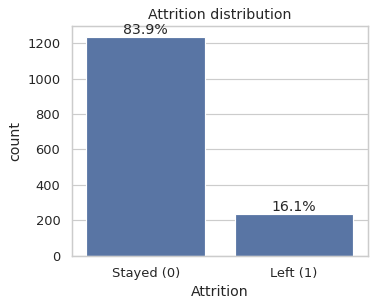

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(x=TARGET, data=df, ax=ax)
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(df):.1%}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
ax.set_xticklabels(["Stayed (0)", "Left (1)"]); ax.set_title("Attrition distribution"); plt.show()

**Observation:** 237 of 1,470 employees (16.1%) left versus 1,233 who stayed, a ratio of about 5.2 to 1. The data is clearly imbalanced, so we use stratified splitting/CV, `class_weight='balanced'`, and PR-AUC/F1 instead of accuracy. A model that always predicts "stays" would score 83.9% accuracy while catching no leavers.

### Visualisation 2 — Skewness and outliers in numeric features

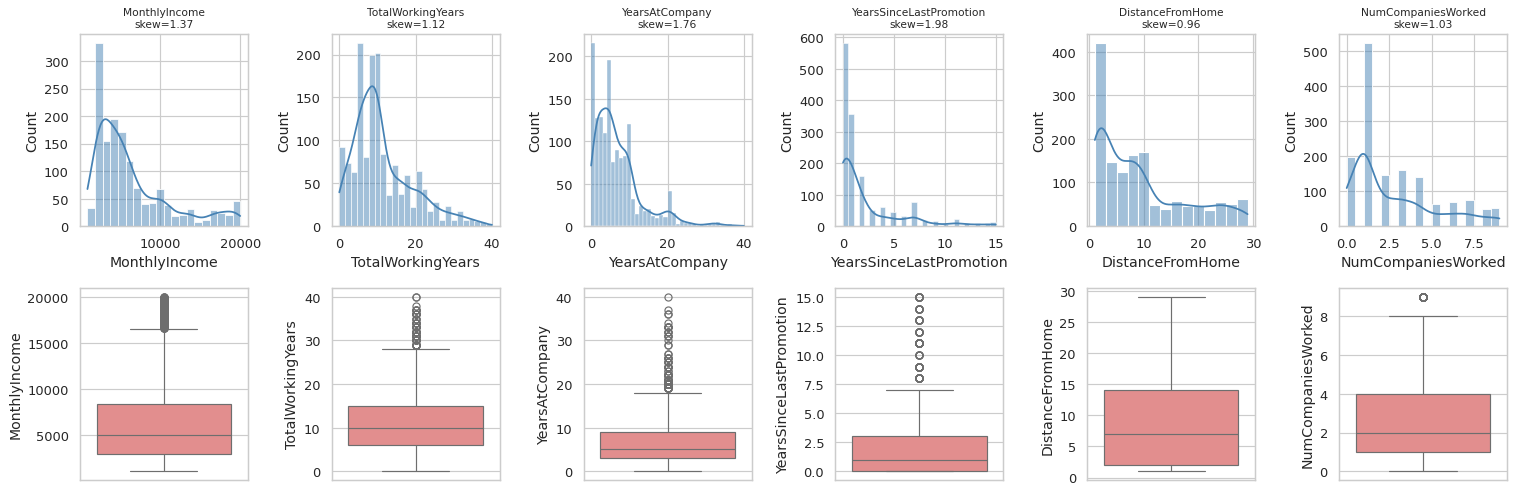

In [6]:
skewed = ["MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "YearsSinceLastPromotion", "DistanceFromHome", "NumCompaniesWorked"]
fig, axes = plt.subplots(2, len(skewed), figsize=(3*len(skewed), 6))
for i, c in enumerate(skewed):
    sns.histplot(df[c], kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"{c}\nskew={df[c].skew():.2f}", fontsize=9)
    sns.boxplot(y=df[c], ax=axes[1, i], color="lightcoral")
plt.tight_layout(); plt.show()

**Observation:** all six variables are right-skewed (skew 0.96–1.98; `YearsSinceLastPromotion` 1.98 and `YearsAtCompany` 1.76 are the worst). By the 1.5×IQR rule, `MonthlyIncome` has 114 outliers, `YearsSinceLastPromotion` 107, `YearsAtCompany` 104, `TotalWorkingYears` 63 and `NumCompaniesWorked` 52, while `DistanceFromHome` has none. These are plausible values (a few senior or long-serving staff), so they are winsorised rather than deleted, using IQR limits learnt from training data only.

### Visualisation 3 — Correlation heatmap

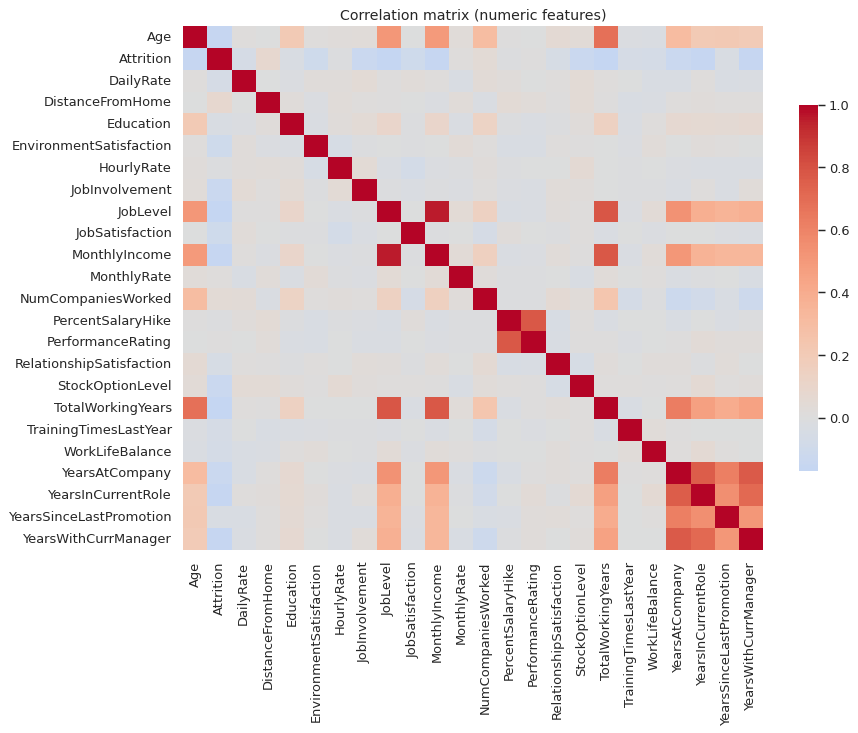

|corr|
JobLevel           MonthlyIncome           0.95
                   TotalWorkingYears       0.78
PercentSalaryHike  PerformanceRating       0.77
MonthlyIncome      TotalWorkingYears       0.77
YearsAtCompany     YearsWithCurrManager    0.77
                   YearsInCurrentRole      0.76
YearsInCurrentRole YearsWithCurrManager    0.71

In [7]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": .7})
ax.set_title("Correlation matrix (numeric features)"); plt.show()

high = corr.abs().where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
display(high[high > 0.7].sort_values(ascending=False).round(2).to_frame("|corr|"))

**Observation:** seven pairs have |r| > 0.7, with `JobLevel`–`MonthlyIncome` the strongest at 0.95. The others are `JobLevel`–`TotalWorkingYears` (0.78), `PercentSalaryHike`–`PerformanceRating` (0.77), `MonthlyIncome`–`TotalWorkingYears` (0.77), `YearsAtCompany`–`YearsWithCurrManager` (0.77), `YearsAtCompany`–`YearsInCurrentRole` (0.76) and `YearsInCurrentRole`–`YearsWithCurrManager` (0.71). This redundancy (multicollinearity) motivates feature selection and L2 regularisation.

### Visualisation 4 — Attrition rate by key categorical features

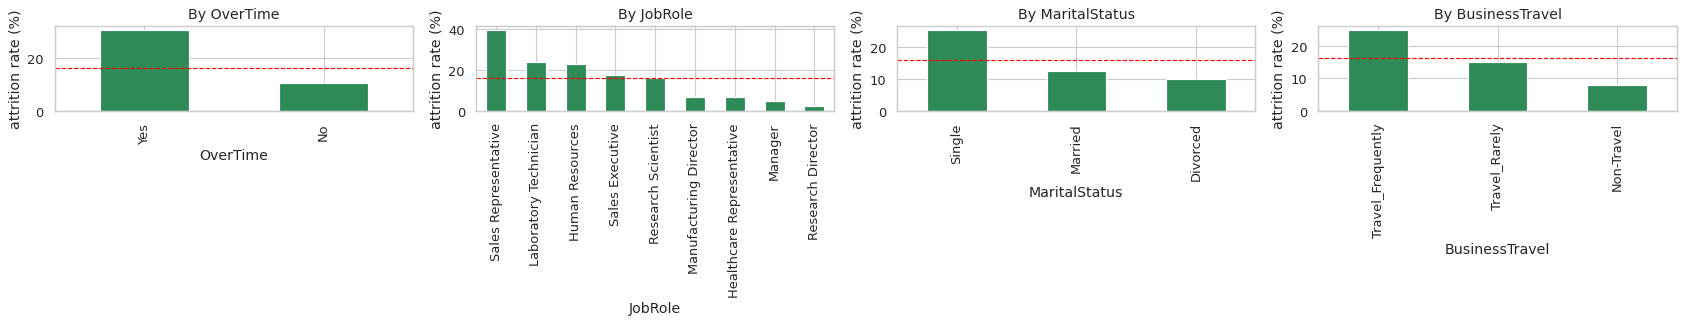

In [8]:
cats = ["OverTime", "JobRole", "MaritalStatus", "BusinessTravel"]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, c in zip(axes, cats):
    (df.groupby(c)[TARGET].mean().sort_values(ascending=False) * 100).plot.bar(ax=ax, color="seagreen")
    ax.axhline(df[TARGET].mean()*100, color="red", ls="--", lw=1)
    ax.set_ylabel("attrition rate (%)"); ax.set_title(f"By {c}")
plt.tight_layout(); plt.show()

**Observation:** overall attrition is 16.1% (dashed line). Overtime workers leave at 30.5% versus 10.4% for non-overtime. Single employees leave at 25.5% (married 12.5%, divorced 10.1%). Frequent travellers leave at 24.9% (non-travellers 8.0%). Sales Representatives have by far the highest rate by role at 39.8%, while Research Directors (2.5%) and Managers (4.9%) have the lowest. Categorical features are clearly informative.

### Visualisation 5 — Numeric drivers by attrition

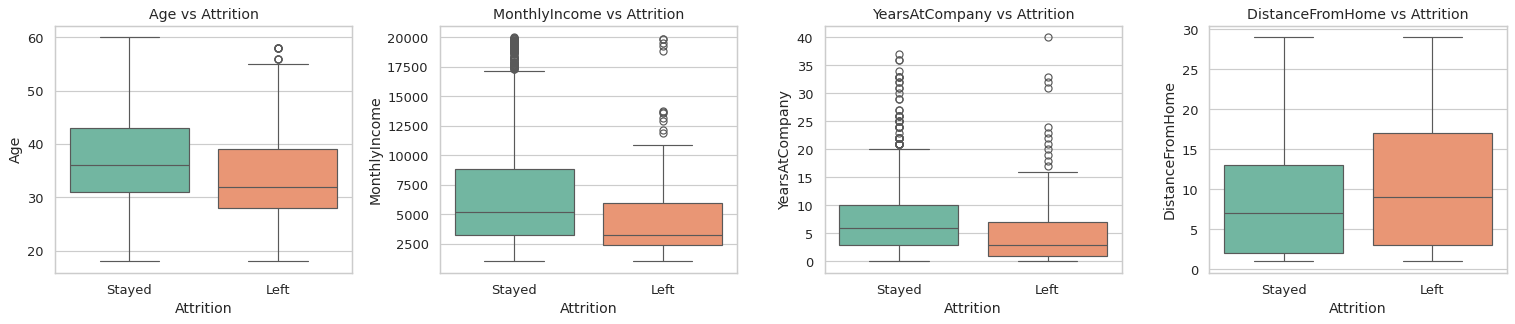

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, ["Age", "MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]):
    sns.boxplot(x=TARGET, y=c, data=df, ax=ax, palette="Set2")
    ax.set_xticklabels(["Stayed", "Left"]); ax.set_title(f"{c} vs Attrition")
plt.tight_layout(); plt.show()

**Observation:** leavers are younger (median age 32 vs 36), earn much less (median monthly income 3,202 vs 5,204), have shorter tenure (median 3 vs 6 years at the company) and live slightly farther away (median distance 9 vs 7).

### Visualisation 6 — Attrition by ordinal satisfaction / level features

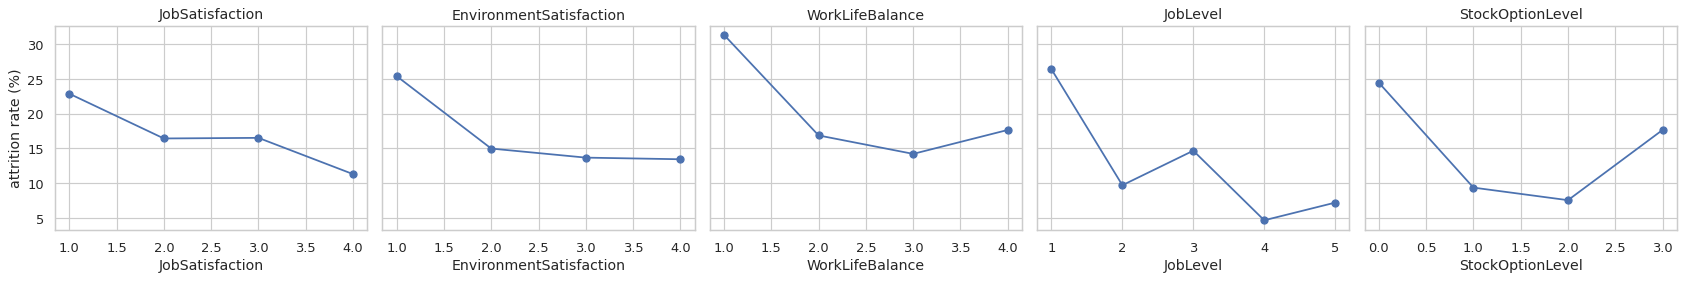

In [10]:
ords = ["JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance", "JobLevel", "StockOptionLevel"]
fig, axes = plt.subplots(1, len(ords), figsize=(4*len(ords), 3.5), sharey=True)
for ax, c in zip(axes, ords):
    (df.groupby(c)[TARGET].mean()*100).plot(marker="o", ax=ax); ax.set_title(c); ax.set_ylabel("attrition rate (%)")
plt.tight_layout(); plt.show()

**Observation:** attrition is highest for the lowest ratings: 22.8% at job satisfaction 1 versus 11.3% at level 4, 25.4% at environment satisfaction 1 versus about 13.5–15% at levels 2–4, and 31.2% at work-life balance 1 versus about 14–18% at levels 2–4. Attrition drops sharply with seniority (26.3% at job level 1 vs 4.7% at level 4) and with stock options (24.4% at level 0 vs 7.6–9.4% at levels 1–2). The pattern is not perfectly monotonic (e.g. stock option level 3 is only a small group), so the ratings are kept as ordered numbers and not one-hot encoded.

## 4. Train / Test Split (before any fitting)
The split is the first modelling step; the test set stays untouched until the final evaluation. Stratification preserves the ~16% attrition rate in both sets.

In [11]:
X = df.drop(columns=[TARGET]); y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Attrition rate  train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))

Train: (1176, 30) | Test: (294, 30)
Attrition rate  train: 0.162 | test: 0.160


## 5. Preprocessing Design

| Issue | Technique | Learnt from |
|---|---|---|
| Missing values (none here, but kept for robustness) | `SimpleImputer` (median numeric / most-frequent categorical) | train only |
| Outliers / skew | Custom `IQRClipper` (winsorise at Q1−1.5·IQR, Q3+1.5·IQR) | train only |
| Scaling | `StandardScaler` | train only |
| Ordinal categorical (`BusinessTravel`) | `OrdinalEncoder` with explicit order Non-Travel < Rarely < Frequently | fixed order |
| Nominal categorical (`Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`) | `OneHotEncoder(handle_unknown="ignore", drop="if_binary")` | train only |
| Integer ratings (satisfaction, `JobLevel`, `Education`, …) | kept as ordered numeric | — |
| Feature construction | Stateless `FeatureBuilder` (ratios, averages) | no statistics learnt |
| Feature selection | `VarianceThreshold` + `SelectKBest(mutual_info, k=20)` | train only |
| Class imbalance | `class_weight="balanced"` + stratified CV | — |

In [12]:
class IQRClipper(BaseEstimator, TransformerMixin):
    """Winsorise numeric columns with IQR bounds learnt in fit() (training data only)."""
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        q1, q3 = np.nanpercentile(X, 25, axis=0), np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1
        self.lower_, self.upper_ = q1 - self.factor*iqr, q3 + self.factor*iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)
    def get_feature_names_out(self, names=None):
        return np.asarray(names)


class FeatureBuilder(BaseEstimator, TransformerMixin):
    """Stateless feature construction -> cannot leak (nothing is learnt from data)."""
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X["IncomePerJobLevel"]   = X["MonthlyIncome"] / X["JobLevel"].clip(lower=1)
        X["IncomePerWorkYear"]   = X["MonthlyIncome"] / (X["TotalWorkingYears"] + 1)
        X["TenureRatio"]         = X["YearsAtCompany"] / (X["TotalWorkingYears"] + 1)
        X["PromotionGap"]        = X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)
        X["YearsPerCompany"]     = X["TotalWorkingYears"] / (X["NumCompaniesWorked"] + 1)
        X["ManagerStability"]    = X["YearsWithCurrManager"] / (X["YearsAtCompany"] + 1)
        sat = ["EnvironmentSatisfaction", "JobSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance", "JobInvolvement"]
        X["AvgSatisfaction"]     = X[sat].mean(axis=1)
        return X

## 6. Leakage-Free Pipeline

In [13]:
ordinal_cols = ["BusinessTravel"]
travel_order = [["Non-Travel", "Travel_Rarely", "Travel_Frequently"]]

# Column selectors are named functions (not lambdas) so the fitted pipeline can be saved with joblib.
# They are evaluated on the data seen at fit time.
def numeric_sel(d):
    return d.select_dtypes("number").columns.tolist()

def nominal_sel(d):
    return [c for c in d.select_dtypes(exclude="number").columns if c not in ordinal_cols]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clip",   IQRClipper(factor=1.5)),
    ("scale",  StandardScaler()),
])
ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=travel_order, handle_unknown="use_encoded_value", unknown_value=-1)),
    ("scale",  StandardScaler()),
])
nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_sel),
    ("ord", ordinal_pipe, ordinal_cols),
    ("nom", nominal_pipe, nominal_sel),
])

full_pipe = Pipeline([
    ("features", FeatureBuilder()),
    ("prep",     preprocessor),
    ("var",      VarianceThreshold(0.0)),
    ("select",   SelectKBest(partial(mutual_info_classif, random_state=RANDOM_STATE), k=20)),
    ("model",    LogisticRegression(class_weight="balanced", C=0.5, max_iter=2000, random_state=RANDOM_STATE)),
])
full_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('prep', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Cross-validation on the training set only
Every step (imputer, clipper, scaler, encoders, selector, model) is re-fitted on each fold's training portion, so validation folds never influence preprocessing.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_validate(full_pipe, X_train, y_train, cv=cv,
                        scoring={"pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1", "recall": "recall"})
cv_table = pd.DataFrame(scores).drop(columns=["fit_time", "score_time"]).agg(["mean", "std"]).round(3)
cv_table

,test_pr_auc,test_roc_auc,test_f1,test_recall
mean,0.535,0.784,0.449,0.668
std,0.091,0.067,0.065,0.134


**Result:** across 5 stratified folds the baseline reaches PR-AUC 0.535 (± 0.091), ROC-AUC 0.784, F1 0.449 and recall 0.668. The fold-to-fold spread is fairly large because each validation fold has only about 38 leavers. PR-AUC is far above the no-skill level of about 0.16, so the pipeline extracts real signal.

### Final fit on training data → one evaluation on the untouched test set

Test PR-AUC: 0.522   (no-skill baseline = 0.160)
              precision    recall  f1-score   support

      Stayed       0.92      0.75      0.83       247
        Left       0.34      0.66      0.45        47

    accuracy                           0.74       294
   macro avg       0.63      0.71      0.64       294
weighted avg       0.83      0.74      0.77       294



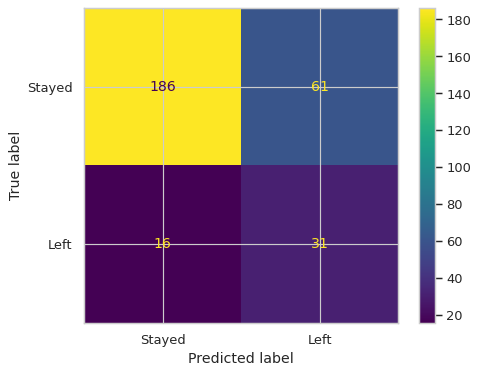

In [15]:
full_pipe.fit(X_train, y_train)
proba = full_pipe.predict_proba(X_test)[:, 1]
pred = full_pipe.predict(X_test)
print(f"Test PR-AUC: {average_precision_score(y_test, proba):.3f}   (no-skill baseline = {y_test.mean():.3f})")
print(classification_report(y_test, pred, target_names=["Stayed", "Left"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Stayed", "Left"]); plt.show()

**Result:** on the untouched test set (294 employees, 47 leavers) PR-AUC is 0.522 against a 0.160 baseline, consistent with the CV estimate. The model finds 66% of leavers (recall 0.66) but only 34% of its "Left" predictions are correct (precision 0.34). This trade-off comes from `class_weight='balanced'` and is acceptable when missing a leaver is costlier than a false alarm. Threshold tuning is left for Part 2.

### Which features survived selection?

53 features after encoding -> 20 selected:
['num__Age', 'num__Education', 'num__JobInvolvement', 'num__MonthlyIncome', 'num__RelationshipSatisfaction', 'num__StockOptionLevel', 'num__TotalWorkingYears', 'num__YearsAtCompany', 'num__YearsInCurrentRole', 'num__TenureRatio', 'num__YearsPerCompany', 'num__ManagerStability', 'num__AvgSatisfaction', 'ord__BusinessTravel', 'nom__EducationField_Other', 'nom__JobRole_Laboratory Technician', 'nom__JobRole_Manager', 'nom__JobRole_Sales Representative', 'nom__MaritalStatus_Single', 'nom__OverTime_Yes']


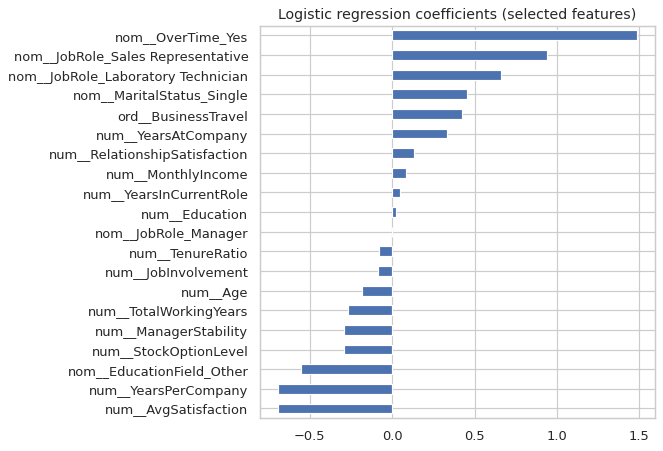

In [16]:
names = full_pipe.named_steps["prep"].get_feature_names_out()
names = names[full_pipe.named_steps["var"].get_support()]
kept = names[full_pipe.named_steps["select"].get_support()]
print(len(names), "features after encoding ->", len(kept), "selected:")
print(list(kept))

coefs = pd.Series(full_pipe.named_steps["model"].coef_[0], index=kept).sort_values()
coefs.plot.barh(figsize=(6, 6), title="Logistic regression coefficients (selected features)"); plt.show()

**Result:** 53 encoded features were reduced to 20. The selected set includes the main drivers seen in the EDA: `OverTime_Yes`, `MaritalStatus_Single`, `MonthlyIncome`, `StockOptionLevel`, `Age`, `BusinessTravel`, `JobRole_Sales Representative`, `YearsAtCompany` and two engineered features (`TenureRatio`, `AvgSatisfaction`). Mutual information also keeps a few weaker features (e.g. `Education`), which the L2-regularised model can down-weight.

## 7. Leakage Demonstration
**Wrong:** run feature selection (which uses the target) on *all* rows, then split. The test labels have then influenced which features are kept. **Right:** the pipeline above, where selection is fitted on training data only. Below, the leaky approach reports a noticeably higher PR-AUC (0.578 vs 0.522) on the same test rows, a gain that comes only from leakage, not from a better model. This is why the leaky estimate cannot be trusted.

In [17]:
Xd = pd.get_dummies(X, dtype=float)
Xd_sel = SelectKBest(partial(mutual_info_classif, random_state=RANDOM_STATE), k=20).fit_transform(Xd, y)   # LEAK: sees y of test rows
Xtr, Xte, ytr, yte = train_test_split(Xd_sel, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
sc = StandardScaler().fit(Xtr)
leaky = LogisticRegression(class_weight="balanced", C=0.5, max_iter=2000).fit(sc.transform(Xtr), ytr)
print(f"Leaky approach       PR-AUC: {average_precision_score(yte, leaky.predict_proba(sc.transform(Xte))[:, 1]):.3f}")
print(f"Pipeline (correct)   PR-AUC: {average_precision_score(y_test, proba):.3f}")

Leaky approach       PR-AUC: 0.578
Pipeline (correct)   PR-AUC: 0.522


## 8. Save the Pipeline

In [18]:
joblib.dump(full_pipe, "attrition_pipeline.joblib")
print("Saved attrition_pipeline.joblib")

Saved attrition_pipeline.joblib


## 9. Summary
- **Framing:** binary classification of `Attrition` (237 leavers vs 1,233 stayers, 16.1%); PR-AUC primary, recall/F1 secondary.
- **Cleaning:** dropped 3 constant columns and 1 ID column; confirmed no missing values (imputers kept in the pipeline for robustness); winsorised the skewed features (e.g. 114 IQR outliers in `MonthlyIncome`) with train-only IQR bounds.
- **Encoding & scaling:** ordinal encoding for `BusinessTravel`, one-hot for nominal features (53 features after encoding), integer ratings kept as ordered numerics, standard scaling.
- **Feature engineering:** 7 constructed features; 20 selected by mutual information after a variance filter.
- **Imbalance:** stratified split/CV and a class-weighted model.
- **Leakage control:** one `Pipeline` + `ColumnTransformer`; every statistic is learnt inside `fit()` on training data only.
- **Baseline result:** 5-fold CV PR-AUC 0.535 ± 0.091 and test PR-AUC 0.522, about 3.3× the no-skill baseline of 0.160. Test recall for leavers is 0.66 (precision 0.34).
